### Imports & Configuration

In [1]:
import torch
import pandas as pd
import numpy as np
import os
from pathlib import Path
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    ModernBertForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
    EarlyStoppingCallback
)
import evaluate
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc,
    average_precision_score
)
from pyprojroot import here

# Reproducibility
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

# Project path anchors
# 'here()' will find the project root locally or in Colab if a .git or pyproject.toml exists
try:
    REPO_ROOT = here()
except RuntimeError:
    # Fallback for Colab if drive is already mounted and pyprojroot fails
    REPO_ROOT = Path('/content/drive/MyDrive/project-jail-break')

PROCESSED_DATA_DIR = REPO_ROOT / "data" / "processed"

MODEL_ID = "answerdotai/ModernBERT-base"
MAX_LENGTH = 1500

## Data Loading and Preprocessing

In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

single_X_train = pd.read_csv(PROCESSED_DATA_DIR / "singleturn_X_train.csv", usecols=['conversation_id', 'conversation'])
single_y_train = pd.read_csv(PROCESSED_DATA_DIR / "singleturn_Y_train.csv")

single_X_val = pd.read_csv(PROCESSED_DATA_DIR / "singleturn_X_val.csv", usecols=['conversation_id', 'conversation'])
single_y_val = pd.read_csv(PROCESSED_DATA_DIR / "singleturn_Y_val.csv")

single_X_test = pd.read_csv(PROCESSED_DATA_DIR / "singleturn_X_test.csv", usecols=['conversation_id', 'conversation'])
single_y_test = pd.read_csv(PROCESSED_DATA_DIR / "singleturn_Y_test.csv")

multi_X_test = pd.read_csv(PROCESSED_DATA_DIR / "multiturn_X_test.csv", usecols=['conversation_id', 'conversation'])
multi_y_test = pd.read_csv(PROCESSED_DATA_DIR / "multiturn_Y_test.csv")

#merge datasets on conversation id col
single_train_df = pd.merge(single_X_train, single_y_train, on="conversation_id")
single_val_df = pd.merge(single_X_val, single_y_val, on="conversation_id")
single_test_df = pd.merge(single_X_test, single_y_test, on="conversation_id")
multi_df = pd.merge(multi_X_test, multi_y_test, on="conversation_id")

#convert merged dfs to huggingface dfs for use in model
hf_dataset_single_train = Dataset.from_pandas(single_train_df)
hf_dataset_single_val = Dataset.from_pandas(single_val_df)
hf_dataset_single_test = Dataset.from_pandas(single_test_df)
hf_dataset_multi = Dataset.from_pandas(multi_df)

In [3]:
def tokenization(convos):
    tokenized = tokenizer(
        convos["conversation"],
        truncation_side="left",
        truncation=True,
        max_length = MAX_LENGTH,
        padding = False
    )
    tokenized["labels"] = [int(label) for label in convos["harm"]]

    return tokenized

tokenized_dataset_single_train = hf_dataset_single_train.map(tokenization, batched=True)
tokenized_dataset_single_train.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

tokenized_dataset_single_val = hf_dataset_single_val.map(tokenization, batched=True)
tokenized_dataset_single_val.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

tokenized_dataset_single_test = hf_dataset_single_test.map(tokenization, batched=True)
tokenized_dataset_single_test.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

def tokenization_multi(convos):
    tokenized = tokenizer(
        convos["conversation"],
        truncation_side="left",
        truncation=True,
        max_length = 4000,
        padding = False
    )
    tokenized["labels"] = [int(label) for label in convos["harm"]]

    return tokenized

tokenized_dataset_multi = hf_dataset_multi.map(tokenization_multi, batched=True)
tokenized_dataset_multi.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/38281 [00:00<?, ? examples/s]

Map:   0%|          | 0/9571 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

## Model Initialization

In [4]:
def model_init(trial=None):
    # This guarantees a fresh pretrained model is loaded for every trial
    return ModernBertForSequenceClassification.from_pretrained(
        MODEL_ID,
        num_labels=2,
    )
#dynamic padding at batch level
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## Evaluation Metric Setup

In [5]:
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)
    metrics = {}
    metrics.update(accuracy_metric.compute(predictions=predictions, references=labels))
    metrics.update(precision_metric.compute(predictions=predictions, references=labels))
    metrics.update(recall_metric.compute(predictions=predictions, references=labels))
    metrics.update(f1_metric.compute(predictions=predictions, references=labels))

    # Calculate PR AUC correctly using probabilities
    probabilities = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    precision, recall, _ = precision_recall_curve(labels, probabilities)
    pr_auc = auc(recall, precision)
    metrics["pr_auc"] = pr_auc
    return metrics

## Trainer Setup and Execution

In [6]:
training_args = TrainingArguments(
    output_dir= "./modernbert-harm-classifier",
    eval_strategy= "epoch",
    save_strategy= "epoch",
    per_device_train_batch_size= 16,
    per_device_eval_batch_size= 4,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    eval_accumulation_steps=1,
    fp16=True,
    learning_rate= 2e-5,
    num_train_epochs= 5,
    weight_decay= 0.01,
    load_best_model_at_end= True,
    metric_for_best_model="pr_auc",
    greater_is_better=True,
    report_to= "none"
)

trainer = Trainer(
    model_init=model_init,
    args = training_args,
    train_dataset=tokenized_dataset_single_train,
    eval_dataset=tokenized_dataset_single_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.1),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 3, 6)
    }

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

best_run = trainer.hyperparameter_search(
    hp_space=optuna_hp_space,
    direction="maximize",
    backend="optuna",
    n_trials=5
)

print("Best Hyperparameters:", best_run.hyperparameters)

for param, value in best_run.hyperparameters.items():
    setattr(training_args, param, value)

final_trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=tokenized_dataset_single_train,
    eval_dataset=tokenized_dataset_single_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

# 4. Train and save the optimal model
final_trainer.train()
final_trainer.save_model("./modernbert-harm-classifier-final")
tokenizer.save_pretrained("./modernbert-harm-classifier-final")

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[I 2026-08-06 00:02:05,422] A new study created in memory with name: no-name-935f1996-d7fa-485c-a433-74c2681d66fa


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Pr Auc
1,1.090627,0.168554,0.931773,0.938967,0.928543,0.933726,0.985046
2,0.456082,0.176529,0.938251,0.953063,0.926322,0.939503,0.987247
3,0.239330,0.401888,0.937311,0.953920,0.923496,0.938462,0.986929


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./modernbert-harm-classifier-final/tokenizer_config.json',
 './modernbert-harm-classifier-final/tokenizer.json')

## Evaluation

In [8]:
val_preds = final_trainer.predict(tokenized_dataset_single_val)
single_preds = final_trainer.predict(tokenized_dataset_single_test)
multi_preds = final_trainer.predict(tokenized_dataset_multi)

datasets ={
    "Validation": val_preds.metrics,
    "Single-Turn Test": single_preds.metrics,
    "Multi-Turn Test": multi_preds.metrics,
}

metrics_df = pd.DataFrame(datasets)
print(metrics_df)

                         Validation  Single-Turn Test  Multi-Turn Test
test_loss                  0.196400          0.825397         0.615059
test_accuracy              0.931460          0.853333         0.830000
test_precision             0.966363          0.929648         0.921995
test_recall                0.898870          0.724543         0.721000
test_f1                    0.931395          0.814380         0.809203
test_pr_auc                0.987380          0.907503         0.914415
test_runtime              74.330300         14.311900        43.885900
test_samples_per_second  128.763000        120.529000        45.573000
test_steps_per_second     32.194000         30.185000        11.393000


In [9]:
y_val = val_preds.label_ids
y_val_prob = torch.softmax(torch.tensor(val_preds.predictions), dim=-1)[:,1].numpy()

y_single = single_preds.label_ids
y_single_prob = torch.softmax(torch.tensor(single_preds.predictions), dim=-1)[:,1].numpy()
y_single_pred_class = np.argmax(single_preds.predictions, axis=-1)

y_multi = multi_preds.label_ids
y_multi_prob = torch.softmax(torch.tensor(multi_preds.predictions), dim=-1)[:,1].numpy()
y_multi_pred_class = np.argmax(multi_preds.predictions, axis=-1)

## Plotting ROC AUC Curve

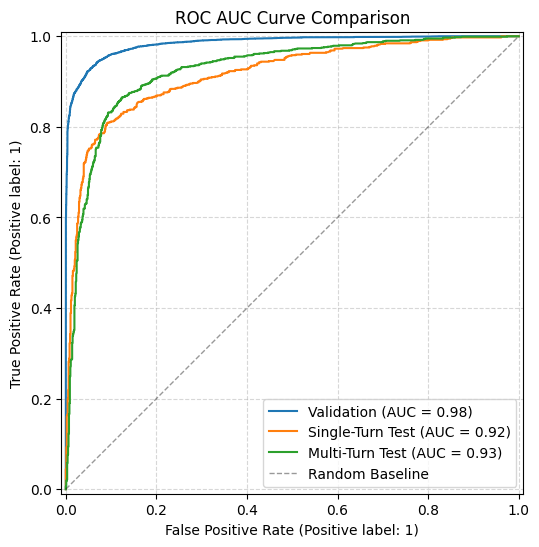

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
d = RocCurveDisplay.from_predictions(y_val, y_val_prob, name="Validation", ax=ax)
RocCurveDisplay.from_predictions(y_single, y_single_prob, name="Single-Turn Test", ax=d.ax_)
RocCurveDisplay.from_predictions(y_multi, y_multi_prob, name="Multi-Turn Test", ax=d.ax_)
d.ax_.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random Baseline")
d.ax_.set_title("ROC AUC Curve Comparison")
d.ax_.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

## Confususion Matrices

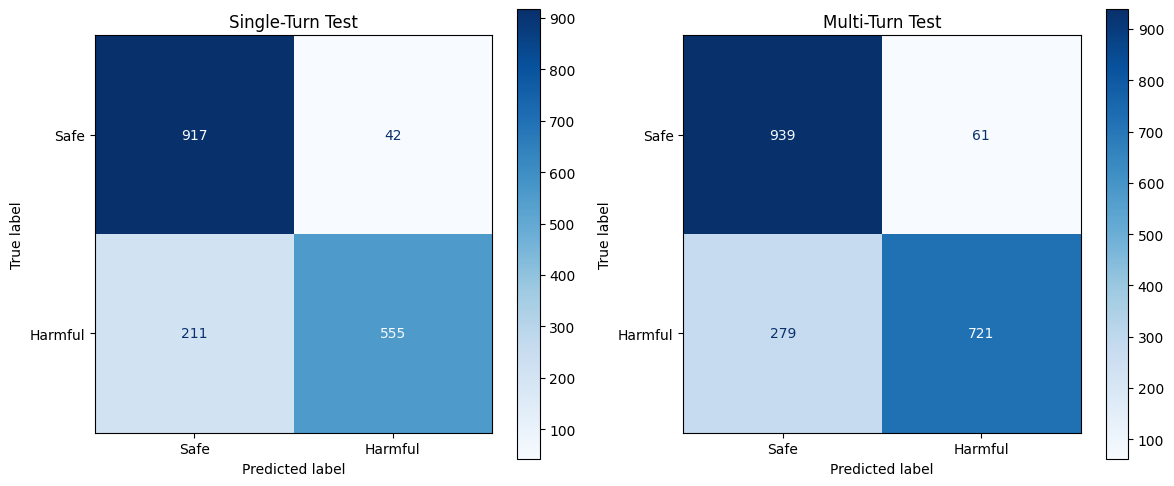

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_single, y_single_pred_class, display_labels=["Safe", "Harmful"], cmap="Blues", ax=axes[0]
)
axes[0].set_title("Single-Turn Test")

ConfusionMatrixDisplay.from_predictions(
    y_multi, y_multi_pred_class, display_labels=["Safe", "Harmful"], cmap="Blues", ax=axes[1]
)
axes[1].set_title("Multi-Turn Test")

plt.tight_layout()
plt.show()

In [12]:
# 1. Ensure predictions exist
if 'single_preds' not in locals():
    print("Predictions not found in memory. Running inference on single-turn test set...")
    single_preds = trainer.predict(tokenized_dataset_single_test)

# 2. Extract probabilities and classes
y_single_prob = torch.softmax(torch.tensor(single_preds.predictions), dim=-1)[:, 1].numpy()
y_single_pred_class = np.argmax(single_preds.predictions, axis=-1)

# 3. Load metadata and merge
test_raw_full = pd.read_csv(PROCESSED_DATA_DIR / "wildguardmix_singleturn_test_sample_full.csv")

single_test_df["prob"] = y_single_prob
single_test_df["pred"] = y_single_pred_class

test_df = single_test_df.merge(
    test_raw_full[["conversation_id", "adversarial"]],
    on="conversation_id",
    how="inner"
)

# 4. Standardize and check accuracy
test_df["adversarial"] = test_df["adversarial"].astype(str).str.strip().str.lower().map({"true": True, "false": False, "1": True, "0": False}).fillna(False)
test_df["correct"]     = test_df["pred"] == test_df["harm"]

# 5. Display breakdown
tbl = (test_df.groupby(["adversarial", "harm"])["correct"]
       .agg(n="size", accuracy="mean").reset_index())
tbl["metric"] = np.where(tbl["harm"] == 1, "recall (harmful)", "specificity (benign)")
tbl["group"]  = np.where(tbl["adversarial"], "adversarial", "normal")

print("--- Performance Breakdown ---")
print(tbl[["group","metric","n","accuracy"]].sort_values(["metric","group"]).to_string(index=False))

--- Performance Breakdown ---
      group               metric   n  accuracy
adversarial     recall (harmful) 351  0.720798
     normal     recall (harmful) 415  0.727711
adversarial specificity (benign) 459  0.930283
     normal specificity (benign) 500  0.980000


## Performance: Adversarial vs Non-Adversarial

In [13]:
# Split the data
adv_subset = test_df[test_df["adversarial"] == True]
non_adv_subset = test_df[test_df["adversarial"] == False]

### Confusion Matrices

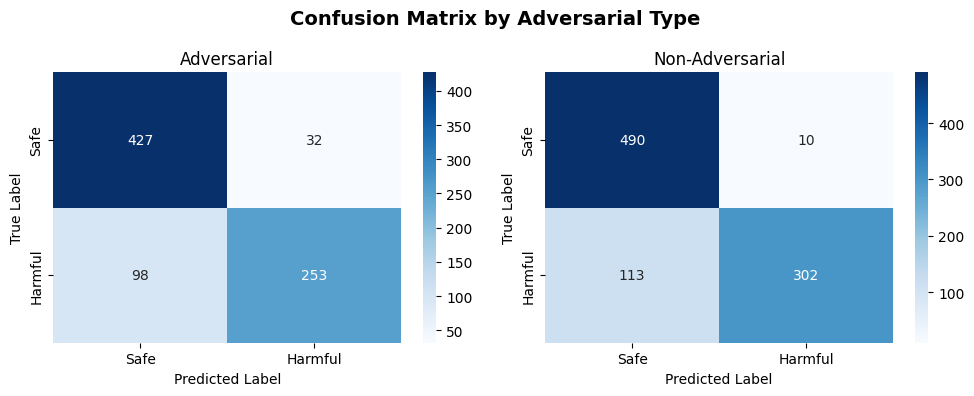

In [14]:
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig1.suptitle("Confusion Matrix by Adversarial Type", fontsize=14, fontweight="bold")

# Adversarial
cm_adv = confusion_matrix(adv_subset["harm"], adv_subset["pred"])
sns.heatmap(cm_adv, annot=True, fmt="d", cmap="Blues", ax=ax1,
            xticklabels=["Safe", "Harmful"], yticklabels=["Safe", "Harmful"])
ax1.set_title("Adversarial")
ax1.set_ylabel("True Label")
ax1.set_xlabel("Predicted Label")

# Non-Adversarial
cm_non = confusion_matrix(non_adv_subset["harm"], non_adv_subset["pred"])
sns.heatmap(cm_non, annot=True, fmt="d", cmap="Blues", ax=ax2,
            xticklabels=["Safe", "Harmful"], yticklabels=["Safe", "Harmful"])
ax2.set_title("Non-Adversarial")
ax2.set_ylabel("True Label")
ax2.set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

### ROC Curve Plots

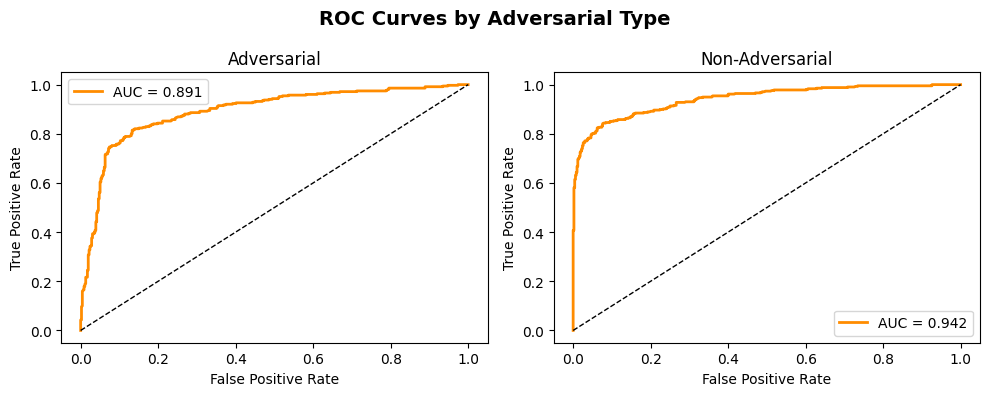

In [15]:
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(10, 4))
fig2.suptitle("ROC Curves by Adversarial Type", fontsize=14, fontweight="bold")

# Adversarial
fpr1, tpr1, _ = roc_curve(adv_subset["harm"], adv_subset["prob"])
auc1 = roc_auc_score(adv_subset["harm"], adv_subset["prob"])
ax3.plot(fpr1, tpr1, label=f"AUC = {auc1:.3f}", color="darkorange", lw=2)
ax3.plot([0, 1], [0, 1], "k--", lw=1)
ax3.set_title("Adversarial")
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.legend()

# Non-Adversarial
fpr2, tpr2, _ = roc_curve(non_adv_subset["harm"], non_adv_subset["prob"])
auc2 = roc_auc_score(non_adv_subset["harm"], non_adv_subset["prob"])
ax4.plot(fpr2, tpr2, label=f"AUC = {auc2:.3f}", color="darkorange", lw=2)
ax4.plot([0, 1], [0, 1], "k--", lw=1)
ax4.set_title("Non-Adversarial")
ax4.set_xlabel("False Positive Rate")
ax4.set_ylabel("True Positive Rate")
ax4.legend()

plt.tight_layout()
plt.show()

### Per-Class Metrics Bar Charts

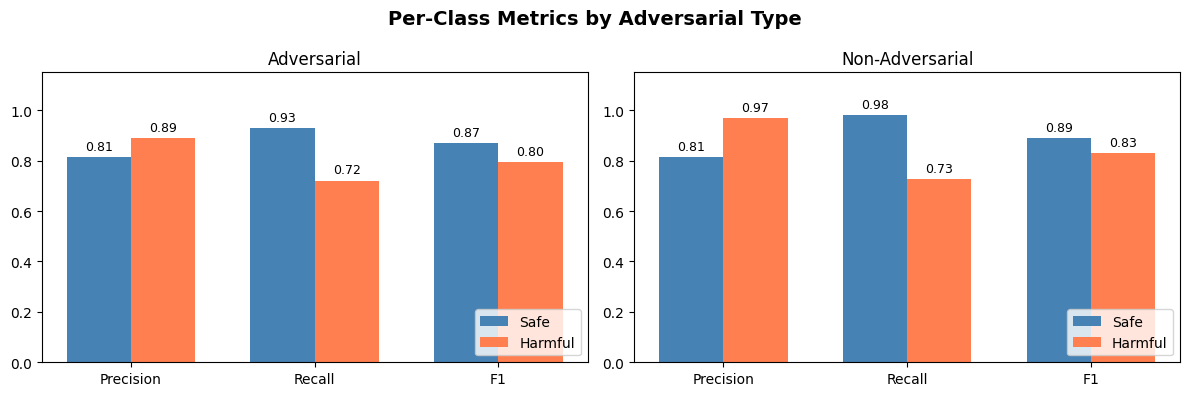

In [16]:
fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(12, 4))
fig3.suptitle("Per-Class Metrics by Adversarial Type", fontsize=14, fontweight="bold")

x = np.arange(3)
width = 0.35
metrics = ["Precision", "Recall", "F1"]

# Adversarial
rep_adv = classification_report(adv_subset["harm"], adv_subset["pred"],
                                target_names=["Safe", "Harmful"],
                                output_dict=True, zero_division=0)

safe_adv = [rep_adv["Safe"]["precision"], rep_adv["Safe"]["recall"], rep_adv["Safe"]["f1-score"]]
harm_adv = [rep_adv["Harmful"]["precision"], rep_adv["Harmful"]["recall"], rep_adv["Harmful"]["f1-score"]]

ax5.bar(x - width/2, safe_adv, width, label="Safe", color="steelblue")
ax5.bar(x + width/2, harm_adv, width, label="Harmful", color="coral")

for container in ax5.containers:
    ax5.bar_label(container, fmt='%.2f', fontsize=9, padding=3)

ax5.set_xticks(x)
ax5.set_xticklabels(metrics)
ax5.set_ylim(0, 1.15)
ax5.set_title("Adversarial")
ax5.legend(loc="lower right")

# Non-Adversarial
rep_non = classification_report(non_adv_subset["harm"], non_adv_subset["pred"],
                                target_names=["Safe", "Harmful"],
                                output_dict=True, zero_division=0)

safe_non = [rep_non["Safe"]["precision"], rep_non["Safe"]["recall"], rep_non["Safe"]["f1-score"]]
harm_non = [rep_non["Harmful"]["precision"], rep_non["Harmful"]["recall"], rep_non["Harmful"]["f1-score"]]

ax6.bar(x - width/2, safe_non, width, label="Safe", color="steelblue")
ax6.bar(x + width/2, harm_non, width, label="Harmful", color="coral")

for container in ax6.containers:
    ax6.bar_label(container, fmt='%.2f', fontsize=9, padding=3)

ax6.set_xticks(x)
ax6.set_xticklabels(metrics)
ax6.set_ylim(0, 1.15)
ax6.set_title("Non-Adversarial")
ax6.legend(loc="lower right")

plt.tight_layout()
plt.show()

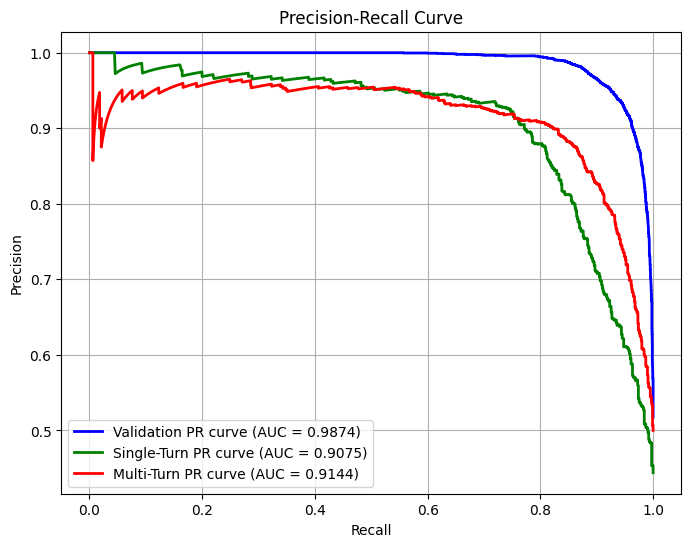

In [17]:
# Calculate Precision-Recall for Validation
precision_val, recall_val, _ = precision_recall_curve(y_val, y_val_prob)
pr_auc_val = auc(recall_val, precision_val)
# Calculate Precision-Recall for Single-Turn Test
precision_single, recall_single, _ = precision_recall_curve(y_single, y_single_prob)
pr_auc_single = auc(recall_single, precision_single)
# Calculate Precision-Recall for Multi-Turn Test
precision_multi, recall_multi, _ = precision_recall_curve(y_multi, y_multi_prob)
pr_auc_multi = auc(recall_multi, precision_multi)
# Plotting PR AUC Curves
plt.figure(figsize=(8, 6))
plt.plot(recall_val, precision_val, color='blue', lw=2,
         label=f'Validation PR curve (AUC = {pr_auc_val:.4f})')
plt.plot(recall_single, precision_single, color='green', lw=2,
         label=f'Single-Turn PR curve (AUC = {pr_auc_single:.4f})')
plt.plot(recall_multi, precision_multi, color='red', lw=2,
         label=f'Multi-Turn PR curve (AUC = {pr_auc_multi:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()